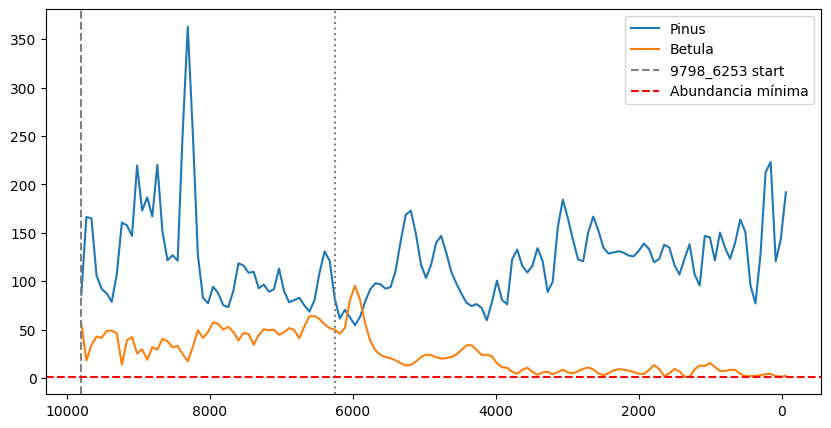


Generando bootstrap...

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 2
         cal BP       Pinus     Betula
46  6536.666187   80.316014  63.887973
47  6465.767626  108.887827  60.761529
48  6394.869065  130.756949  55.395093
49  6323.970504  121.058866  51.495784
50  6253.071942   81.770361  49.885487

Pinus -> Betula
Original: -0.0333
Bootstrap mean: -0.0005, std: 0.0364
p valor:  0.29775


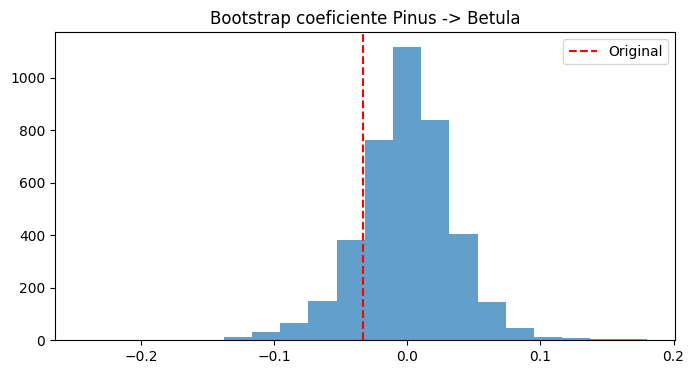

         cal BP     Betula       Pinus
46  6536.666187  63.887973   80.316014
47  6465.767626  60.761529  108.887827
48  6394.869065  55.395093  130.756949
49  6323.970504  51.495784  121.058866
50  6253.071942  49.885487   81.770361

Betula -> Pinus
Original: -0.5911
Bootstrap mean: 0.0070, std: 0.6585
p valor:  0.334


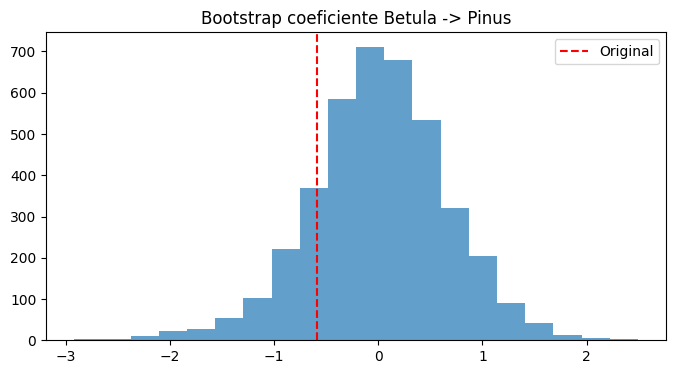

Significativos: 0 (0.00% de válidos)
[[        nan -0.03332737]
 [-0.59109268         nan]]

Proceso terminado correctamente.


In [1]:
#lo mismo pero para un par de especies concreto

sp_1="Pinus"
sp_2="Betula"


import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 4000
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    "9798_6253": (9798, 6253),
    #"6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values


    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        # fila 1 = destino sp2
        # columna 0 = origen sp1
        return A[1][0]
    
    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP" and c != "Temperatura" and c != "Multiplier"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

np.random.seed(42)

especies_ejemplo = [sp for sp in [sp_1, sp_2] if sp in especies_cols]

#plotear las series originales de las dos especies en una misma grafica
#añadir lineas verticales indicando las ventanas de tiempo
plt.figure(figsize=(10,5))
for sp in especies_ejemplo:
    plt.plot(df_original["cal BP"], df_original[sp], label=sp)
for window_name, (cmin, cmax) in WINDOWS.items():
    plt.axvline(cmin, color="gray", linestyle="--", label=f"{window_name} start")
    plt.axvline(cmax, color="gray", linestyle=":")
plt.gca().invert_xaxis()
#añadir linea horizontal en abundancia 1
plt.axhline(1, color="red", linestyle="--", label="Abundancia mínima")
plt.legend()
plt.show()

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

# boot_dfs = [
#     generar_bootstrap_df(df_original, especies_ejemplo)
#     for _ in range(N_BOOTSTRAP)
# ]



# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_ejemplo
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # boot_windows = [
    #     extraer_ventana(df_b, cmin, cmax)
    #     for df_b in boot_dfs
    # ]

    boot_windows = [
        generar_bootstrap_df(df_w, especies_ejemplo)
        for _ in range(N_BOOTSTRAP)
    ]

    

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

  



    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            print(df_w[["cal BP", sp1, sp2]].tail())

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            #printear media y desviación estándar de coefs_boot
            print(f"\n{sp1} -> {sp2}")
            print(f"Original: {coef_original:.4f}")
            print(f"Bootstrap mean: {coefs_boot.mean():.4f}, std: {coefs_boot.std():.4f}")

            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_valor = (n_extremos) / (len(coefs_boot))
            print("p valor: ", p_valor)
            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

            # p2_5 = np.percentile(coefs_boot, 2.5)
            # p97_5 = np.percentile(coefs_boot, 97.5)

            # if coef_original < p2_5:

            #     matriz_sig[i, j] = -1
            #     n_sig += 1
            #     n_low += 1

            # elif coef_original > p97_5:

            #     matriz_sig[i, j] = 1
            #     n_sig += 1
            #     n_high += 1

            #plotear histogramas de la distribución de coeficientes bootstrap para el par de especies
            plt.figure(figsize=(8,4))
            plt.hist(coefs_boot, bins=20, alpha=0.7)
            plt.title(f"Bootstrap coeficiente {sp1} -> {sp2}")
            plt.axvline(coef_original, color="red", linestyle="--", label="Original")
            plt.legend()
            plt.show()


    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    # print("\n--- DIAGNÓSTICO ---")

    # print(f"Pares totales evaluados: {total_pairs}")

    # print(f"Coeficientes originales NaN: {nan_original} "
    #       f"({nan_original/total_pairs*100:.2f}%)")

    # print(f"Coeficientes originales válidos: {valid_original} "
    #       f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        # print(f"Fallos bootstrap: {bootstrap_fail} "
        #       f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        # print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    #print(f"Cola baja: {n_low}")
    #print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    print(resultado["matriz_coeficientes"])


print("\nProceso terminado correctamente.")